In [2]:
import pandas as pd

df = pd.read_parquet("../data/reviews/Elec_5C.parquet")

df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR)...,5,Gotta have GPS!,1370131200,"06 2, 2013"
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bou...",1,Very Disappointed,1290643200,"11 25, 2010"
2,A3N7T0DY83Y4IG,0528881469,C. A. Freeman,"[43, 45]","Well, what can I say. I've had this unit in m...",3,1st impression,1283990400,"09 9, 2010"
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought...",2,"Great grafics, POOR GPS",1290556800,"11 24, 2010"
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we go...,1,"Major issues, only excuses for support",1317254400,"09 29, 2011"


(1689188, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1689188 entries, 0 to 1689187
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   reviewerID      1689188 non-null  object
 1   asin            1689188 non-null  object
 2   reviewerName    1664458 non-null  object
 3   helpful         1689188 non-null  object
 4   reviewText      1689188 non-null  object
 5   overall         1689188 non-null  int64 
 6   summary         1689188 non-null  object
 7   unixReviewTime  1689188 non-null  int64 
 8   reviewTime      1689188 non-null  object
dtypes: int64(2), object(7)
memory usage: 116.0+ MB


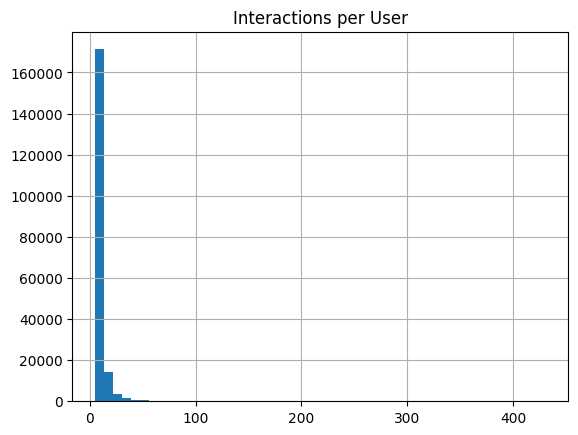

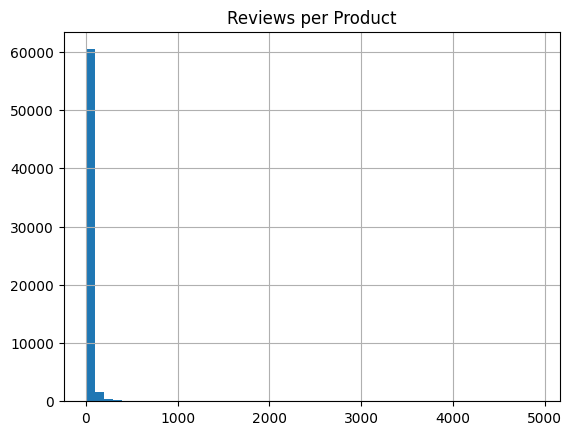

In [3]:
print(df.shape)

df.info()

df.isnull().sum().sort_values(ascending=False)
user_counts = df.groupby("reviewerID").size()

user_counts.describe()

user_counts.quantile([0.25,0.5,0.75,0.9,0.95,0.99])

import matplotlib.pyplot as plt

user_counts.hist(bins=50)
plt.title("Interactions per User")
plt.show()

item_counts = df.groupby("asin").size()

item_counts.describe()

item_counts.quantile([0.25,0.5,0.75,0.9,0.95,0.99])

item_counts.hist(bins=50)
plt.title("Reviews per Product")
plt.show()

In [4]:
n_users = df["reviewerID"].nunique()
n_items = df["asin"].nunique()

possible = n_users * n_items
actual = len(df)

sparsity = 1 - (actual / possible)

print(f"Sparsity: {sparsity:.6f}")

Sparsity: 0.999861


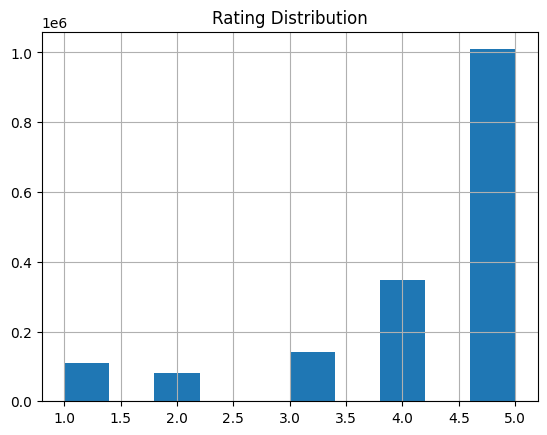

<Axes: xlabel='date'>

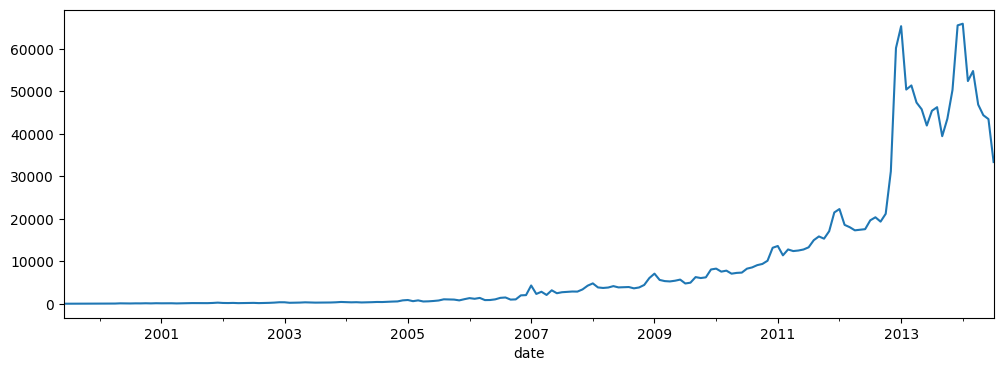

In [5]:
df["overall"].value_counts().sort_index()
df["overall"].hist()
plt.title("Rating Distribution")
plt.show()


df["date"] = pd.to_datetime(
    df["unixReviewTime"],
    unit="s"
)

df["date"].min()
df["date"].max()


(
    df
    .set_index("date")
    .resample("M")
    .size()
    .plot(figsize=(12,4))
)

In [6]:
interactions = df[
    [
        "reviewerID",
        "asin",
        "overall",
        "unixReviewTime"
    ]
].copy()

interactions.to_parquet(
    "../data/interactions.parquet"
)

In [7]:
df.columns

Index(['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText',
       'overall', 'summary', 'unixReviewTime', 'reviewTime', 'date'],
      dtype='object')

In [9]:
df["asin"].nunique()

63001